# TP Optimisation II:  Accelerated and adaptive stochastic gradient methods

### Nom(s): VIGNAUX
### Prénom(s): Adrien
### Groupe: B1

## Exercise 1: Understanding the Convergence of SGD

Firstly, we study optimization dynamics for a regularized logistic regression problem solved by stochastic gradient descent (SGD).

We want to understand how the variance of the stochastic gradient estimate impacts its convergence, and how to improve it. To do that, we focus on the effect of two hyperparameters:
 1. batch size
 2. learning-rate

We will see how a fixed batch size impacts the convergence and show the advantages of an increasing batch size. In the same way, we will study the effect of decreasing learning-rates.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

# Number of epochs, use larger value for more accurate results
EPOCHS = 750

# Hyperparameters
lr0 = 1e-3          # Initial learning rate
LAMBDA_REG = 1e-4      # L2 regularization strength

#### Creation of the synthetic dataset

We generate features $X \in \mathbb{R}^{m \times n}$ with logarithmically spaced scaling
(ranging from 1 to 1000 across dimensions). This creates strong anisotropy that makes
optimization behavior more interesting and closer to realistic ill-conditioned problems.

In [2]:
def make_synthetic_logistic(m=5000, n=40, seed=0):
    """Generate ill-conditioned logistic regression dataset."""
    rng = np.random.default_rng(seed)

    # Features with logarithmically spaced scaling (creates anisotropy)
    X = rng.normal(size=(m, n))
    scales = np.logspace(0, 3, n)   # Scale ranges from 1 to 10000
    X = X * scales

    # Generate binary labels from logistic model
    theta_true = rng.normal(size=n)
    logits = X @ theta_true
    p = 1.0 / (1.0 + np.exp(-logits))
    y = rng.binomial(1, p)

    return X.astype(np.float64), y.astype(np.int32), theta_true


X, y, theta_true = make_synthetic_logistic(m=4000, n=50, seed=0)
print("X shape:", X.shape, "| y shape:", y.shape)
print("y mean (class balance):", y.mean())

X shape: (4000, 50) | y shape: (4000,)
y mean (class balance): 0.49225


/tmp/ipykernel_784692/3371144592.py:13: RuntimeWarning: overflow encountered in exp
  p = 1.0 / (1.0 + np.exp(-logits))


#### Regularized logistic regression minimization problem

We minimize:
$$f(\theta) = \frac{1}{n}\sum_{i=1}^n \ell( x_i^T \theta, y_i) + \frac{\lambda}{2}\|\theta\|^2,$$
where $\theta$ are unknown parameterms and $\ell$ is the logistic loss:
$$
\ell(z, y)
  = -\, y \log \sigma(z)
    - (1 - y)\log(1 - \sigma(z))
$$
and $\lambda > 0$ is a regularization parameter and $\sigma(z) = \frac{1}{1+\exp(-z)}$ is sigmoïde function. 

We implement
the  sigmoid function, the logistic loss, its gradient and its Hessian.


In [3]:
from numpy._core.numeric import zeros_like


def sigmoid(z):
    """Numerically stable sigmoid to avoid overflow."""
    z = z.astype(np.float64, copy=False)
    out = np.empty_like(z, dtype=np.float64)
    # Handle positive and negative values separately for stability
    pos = (z >= 0)
    neg = ~pos
    out[pos] = 1.0 / (1.0 + np.exp(-z[pos]))
    ez = np.exp(z[neg])
    out[neg] = ez / (1.0 + ez)
    return out

def logloss(theta, X, y, lambda_reg=1e-4):
    """Logistic loss with L2 regularization."""
    z = X @ theta
    p = sigmoid(z)
    eps = 1e-12
    # Compute average log loss and add L2 penalty
    loss = 0.0
    loss = -np.mean(y*np.log(p+eps) + (1-y)*np.log(1-p+eps))
    loss += 0.5*lambda_reg*np.sum(theta**2)
    return float(loss)

def grad_logloss(theta, X, y, lambda_reg=1e-4):
    """Gradient of logistic loss (used by SGD)."""
    z = X @ theta   
    p = sigmoid(z)

    # Compute gradient of log loss and add L2 penalty   
    grad = zeros_like(theta, dtype=np.float64)
    
    grad = (X.T @ (p - y)) / X.shape[0]
    grad += lambda_reg*theta
    return grad.astype(np.float64)

## Note, damping is added to ensure Hessian is positive definite for Newton's method
def hess_logloss_full(theta, X, y, lambda_reg=1e-4, damping=1e-8):
    n, d = X.shape
    z = X @ theta
    p = sigmoid(z)

    # Compute Hessian of log loss and add L2 penalty
    H = np.zeros((d,d), dtype=np.float64)

    w_diag = p*(1-p)
    WX = X*w_diag[:,None]
    H = (X.T @ WX)/n
    
    reg = np.zeros((d,d))
    reg[1:,1:] = lambda_reg*np.eye(d-1)
    H += reg + damping*np.eye(d)
    return H


#### Reference optimum $f(\theta^*)$
We will measure progress in the optimization through suboptimality:  $f(\theta_k) - f(\theta^*)$, where $\theta_k$ and  $\theta^*$ denote the model parameters at iteration $k$ and the solution, respectivelly.
A reliable reference value $f(\theta^*)$ can be computed via Newton's method. To save computational time we then utilize a precomputed value.

In [5]:
# Precompute optimal loss value for suboptimality measurements
def newton_solve_opt(X, y, lambda_reg=1e-4, tol=1e-10, max_iter=5000):
    """Compute optimal value via Newton's method (expensive, for reference)."""
    d = X.shape[1]
    theta = np.zeros(d)

    for it in range(max_iter):
        alpha = 0.1
        g = grad_logloss(theta, X, y, lambda_reg)
        ng = np.linalg.norm(g)
        if ng < tol:
            print(f"[Newton] Converged in {it} iterations | ||g||={ng:.2e}")
            break

        # Implement Newton's method update
        # Newton step: theta = theta - \alpha H^{-1} * g
        H = hess_logloss_full(theta, X, y, lambda_reg)
        theta = theta - alpha*(np.linalg.inv(H) @ g)

    f_star = logloss(theta, X, y, lambda_reg)
    print(f"[Newton] f* = {f_star:.12e}")
    return theta, f_star


# Uncomment to recompute f_opt (slow; needed if data or regularization changes)
theta_star, f_opt = newton_solve_opt(X, y, lambda_reg=LAMBDA_REG)

[Newton] Converged in 281 iterations | ||g||=9.04e-11
[Newton] f* = 2.294549140797e-04


#### SGD runner (fixed batch size)

We implement full-epoch SGD with shuffling, mini-batch updates, and per-epoch tracking of the loss, suboptimality, and direction variance.

Direction variance is a measure of SGD noise. Within each epoch, SGD produces a sequence of update directions $d_1, \dots, d_M$ (one per mini-batch). We quantify the variability of the mini-batch directions using the following dimensionless indicator:

$$
\text{dir}_{\text{var}} = \frac{\mathbb{E}\|d_i - \bar{d}\|^2}{\|\bar{d}\|^2}, 
\quad 
\bar{d} = \mathbb{E}[d_i],
$$

where the index $i$ denotes the $i$-th mini-batch.

In [13]:
def run_sgd(
    X, y, lambda_reg=LAMBDA_REG,
    epochs=300, batch_size=8,
    lr0=1e-3, scheduler=None,
    seed=0, f_opt=None
):
    n, d = X.shape
    rng = np.random.default_rng(seed)
    theta = np.zeros(d)
    alpha = 0.1

    hist_loss, hist_subopt, hist_var, hist_epoch = [], [], [], []

    for ep in range(epochs):
        lr = lr0 if scheduler is None else scheduler(ep, lr0)

        idx = rng.permutation(n)
        Xs, ys = X[idx], y[idx]

        dirs = []
        for start in range(0, n, batch_size):
            end = min(start + batch_size, n)
            # Implement SGD search direction
            d = zeros_like(theta, dtype=np.float64)
            g = grad_logloss(theta, Xs[start:end,:], ys[start:end])
            d = -alpha*g
            
            dirs.append(d)
            theta = theta + d

        f = logloss(theta, X, y, lambda_reg)
        hist_loss.append(f)
        hist_subopt.append(f - f_opt)
        hist_epoch.append(ep)

        D = np.stack(dirs, axis=0)

        # Now, we compute variance of SGD directions relative to mean direction
        mean_d = D.mean(axis=0)
        diff = D - mean_d
        num = np.mean(np.sum(diff * diff, axis=1))
        denom = np.linalg.norm(mean_d) ** 2 + 1e-12
        var_dir = num / denom

        hist_var.append(var_dir)

    return {
        "epoch": np.array(hist_epoch),
        "loss": np.array(hist_loss),
        "subopt": np.array(hist_subopt),
        "dir_var": np.array(hist_var),
    }

### Ex1.1: Study the effect of the batch size on convergence of SGD
We run SGD with constant batch sizes 4, 16 and 1024. Here the learning rate is a fixed small constant.

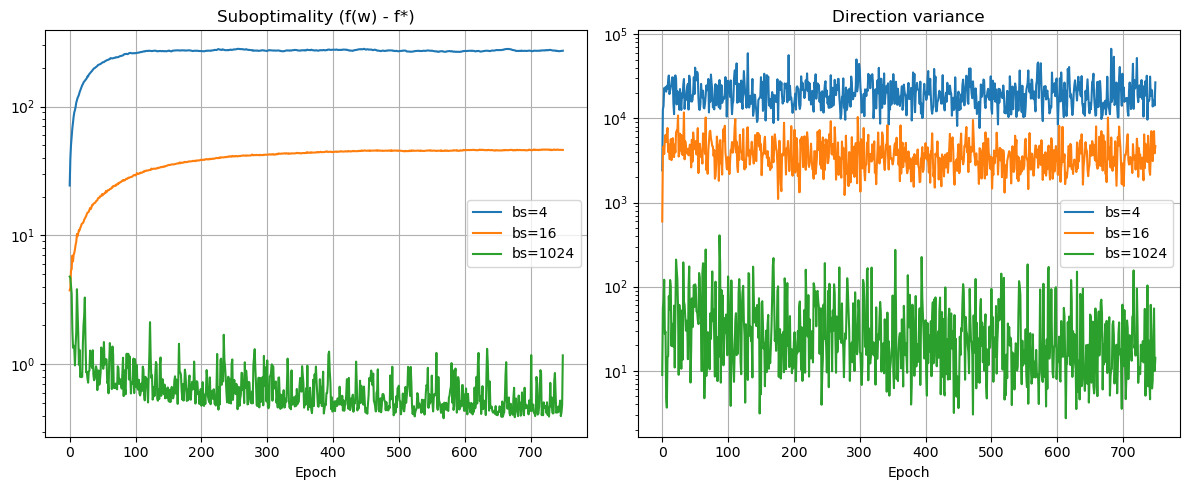

In [14]:
bs_list = [4, 16, 1024]
histories_B = {}

for bs in bs_list:
    h = run_sgd(
        X, y, lambda_reg=LAMBDA_REG,
        epochs=EPOCHS, batch_size=bs,
        lr0=lr0, scheduler=None,
        seed=0, f_opt=f_opt
    )
    histories_B[bs] = h

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
for bs in bs_list:
    plt.semilogy(histories_B[bs]["epoch"], histories_B[bs]["subopt"], label=f"bs={bs}")
plt.title("Suboptimality (f(w) - f*)")
plt.xlabel("Epoch")
plt.grid(True); plt.legend()

plt.subplot(1,2,2)
for bs in bs_list:
    plt.semilogy(histories_B[bs]["epoch"], histories_B[bs]["dir_var"], label=f"bs={bs}")
plt.title("Direction variance")
plt.xlabel("Epoch")
plt.grid(True); plt.legend()

plt.tight_layout()
plt.show()

### Questions 1.1:
1. Explain the relationship between batch size and direction variance shown in the plots. Why does increasing the batch size from 4 to 1024 reduce the variance of SGD update directions? What is the cost of this reduction?

2. From the suboptimality curves in Ex1.1, which batch size reaches the best final solution and why?

### Ex.1.2: SGD with increasing batch size

A common strategy to progressively decrease variance is to start with small batches (cheap, noisy updates)
and gradually increase the batch size (more accurate but more costly updates).

**Linear batch size schedule**: Over epochs, the batch size increases linearly according to:
$$b_{\text{epoch}} = b_{\text{start}} + \frac{\text{epoch}}{\text{max\_epochs}} \cdot (b_{\text{end}} - b_{\text{start}})$$

This allows the optimizer to:
1. **Early phase** (small batches): Explore the landscape quickly with noisy but cheap updates
2. **Late phase** (large batches): Refine the solution with more stable, less noisy updates

We compare a fixed small batch size strategy with this progressive batch size strategy to demonstrate the effectiveness of variance reduction through adaptive batch sizing.

In [ ]:
def run_sgd_progressive(
    X, y, lambda_reg=LAMBDA_REG,
    epochs=300,
    bs_start=8, bs_end=512,
    lr0=1e-3, seed=0, f_opt=None
):
    n, d = X.shape
    rng = np.random.default_rng(seed)
    theta = np.zeros(d)

    hist_loss, hist_subopt, hist_var, hist_epoch = [], [], [], []

    for ep in range(epochs):

        # Implement progressive (linearly-increasing) batch size scheduler 
        bs = 1
        # bs = ...

        idx = rng.permutation(n)
        Xs, ys = X[idx], y[idx]

        dirs = []
        for start in range(0, n, bs):
            end = min(start + bs, n)

            # Implement SGD update with current batch size
            d = zeros_like(theta, dtype=np.float64)    
            # d = ...

            dirs.append(d)
            theta = theta + d

        f = logloss(theta, X, y, lambda_reg)
        hist_loss.append(f)
        hist_subopt.append(f - f_opt)
        hist_epoch.append(ep)

        # Store variances of directions for current batch size
        D = np.stack(dirs, axis=0)
        mean_d = D.mean(axis=0)
        diff = D - mean_d
        num = np.mean(np.sum(diff * diff, axis=1))
        denom = np.linalg.norm(mean_d) ** 2 + 1e-12
        hist_var.append(num / denom)

    return {
        "epoch": np.array(hist_epoch),
        "loss": np.array(hist_loss),
        "subopt": np.array(hist_subopt),
        "dir_var": np.array(hist_var),
    }

UndefVarError: UndefVarError: `def` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [ ]:
bs_start, bs_end = 16, 2048

hist_fixedC = run_sgd(
    X, y, lambda_reg=LAMBDA_REG,
    epochs=EPOCHS, batch_size=bs_start,
    lr0=lr0, scheduler=None,
    seed=0, f_opt=f_opt
)

hist_prog = run_sgd_progressive(
    X, y, lambda_reg=LAMBDA_REG,
    epochs=EPOCHS,
    bs_start=bs_start, bs_end=bs_end,
    lr0=lr0,
    seed=0, f_opt=f_opt
)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.semilogy(hist_fixedC["epoch"], hist_fixedC["subopt"], label="Fixed small batch")
plt.semilogy(hist_prog["epoch"], hist_prog["subopt"], label="Progressive batch")
plt.title("Suboptimality (f(w) - f*)")
plt.xlabel("Epoch")
plt.grid(True); plt.legend()

plt.subplot(1,2,2)
plt.semilogy(hist_fixedC["epoch"], hist_fixedC["dir_var"], label="Fixed small batch")
plt.semilogy(hist_prog["epoch"], hist_prog["dir_var"], label="Progressive batch")
plt.title("Direction variance")
plt.xlabel("Epoch")
plt.grid(True); plt.legend()

plt.tight_layout()
plt.show()

UndefVarError: UndefVarError: `LAMBDA_REG` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

### Questions 1.2:
1. Comparing the progressive batch strategy with fixed small batch, which approach reaches lower final suboptimality? Why might progressive batching help or hurt the direction variance in the early vs late phases?

2. Based on the obtained results, what is the main advantage of starting with small batches and increasing to large batches over simply using a fixed medium batch size throughout training?

### Experiment 1.3:  Effect of the learning rate on the performance of SGD

Here we consider a fixed batch size and we study the effect of the learning rate, by dynamically decreasing it thanks to our polynomial scheduler.
We compare the scheduler with a constant learning-rate.

#### Polynomial learning rate scheduler

To reduce noise and improve convergence in later stages, we consider an adaptive learning rate strategy. We implement a polynomial decay schedule:

$$\alpha_k = \frac{\alpha_0}{(1 + \rho k)^p},$$

where $\alpha_0$ is the initial learning rate, $\rho$ controls the decay rate, $k$ is the epoch, and $p$ is the power (typically 1).

This schedule starts with a larger learning rate (step size) for exploration and gradually decreases it, allowing the optimizer to make fine adjustments near the optimum without overshooting.

In [ ]:
def poly_scheduler(epoch, lr0, decay=5e-3, power=1.0):
    """Polynomial learning rate scheduler."""
    # Implement polynomial learning rate decay
    lr = lr0
    # lr = ...
    return lr

UndefVarError: UndefVarError: `def` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [ ]:
batch_size_fixed = 16

hist_fixed = run_sgd(
    X, y, lambda_reg=LAMBDA_REG,
    epochs=EPOCHS, batch_size=batch_size_fixed,
    lr0=lr0, scheduler=None,
    seed=0, f_opt=f_opt
)

hist_sched = run_sgd(
    X, y, lambda_reg=LAMBDA_REG,
    epochs=EPOCHS, batch_size=batch_size_fixed,
    lr0=lr0,
    scheduler=lambda ep, lr0: poly_scheduler(ep, lr0, decay=0.02),
    seed=0, f_opt=f_opt
)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.semilogy(hist_fixed["epoch"], hist_fixed["subopt"], label="Fixed LR")
plt.semilogy(hist_sched["epoch"], hist_sched["subopt"], label="Poly scheduler")
plt.title("Suboptimality (f(w) - f*)")
plt.xlabel("Epoch")
plt.grid(True); plt.legend()

plt.subplot(1,2,2)
plt.semilogy(hist_fixed["epoch"], hist_fixed["dir_var"], label="Fixed LR")
plt.semilogy(hist_sched["epoch"], hist_sched["dir_var"], label="Poly scheduler")
plt.title("Direction variance")
plt.xlabel("Epoch")
plt.grid(True); plt.legend()

plt.tight_layout()
plt.show()

UndefVarError: UndefVarError: `LAMBDA_REG` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

### Questions 1.3:
1. Compare the convergence behavior of fixed learning rate vs polynomial scheduler in Ex1.3. Explain why does decreasing the learning rate over time helps in the later stages of optimization?

2. How does the polynomial scheduler affect the direction variance as the algorithm progresses? Does the decreasing learning rate help stabilize or destabilize the gradient estimates?

## Exercise 2 – Variants of SGD and variance reduction methods
We now extend the basic SGD framework with additional stochastic optimization strategies.

### Exercise 2.1: Accelerated and Adaptive Stochastic Gradient Methods

The main limitation of basic gradient-type methods is their slow convergence, a behavior often attributed to the difficulty of selecting an appropriate learning rate (step size). To address this challenge, a wide range of accelerated and adaptive variants of stochastic gradient descent (SGD) have been developed.

We summarize here the update rules for the different methods that we will test. Let $g_k$ denote a (possibly stochastic) gradient evaluated at the current iterate $\theta_k$, and let $\alpha_k > 0$ denote the learning rate (step size).


#### SGD

$$
\theta_{k+1} = \theta_k - \alpha_k g_k.
$$


#### Nesterov Accelerated Gradient (NAG)

NAG computes the gradient at a look-ahead position and combines it with a momentum term.

Let $\beta \in (0,1)$ be the momentum parameter. The full update reads:

$$
\begin{aligned}
\tilde{\theta}_k &= \theta_k - \alpha_k \beta v_k 
\quad \text{(look-ahead position)}, \\
\tilde{g}_k &= \nabla f(\tilde{\theta}_k) 
\quad \text{(or stochastic estimate)}, \\
v_{k+1} &= \beta v_k + \tilde{g}_k, \\
\theta_{k+1} &= \theta_k - \alpha_k v_{k+1}.
\end{aligned}
$$


#### AdaGrad

AdaGrad updates the parameters $\theta$ at iteration $k$ in a component-wise manner:

$$
\theta_{k+1}(j)
= \theta_k(j)
- \frac{\alpha_k}{\sqrt{G_k(j) + \epsilon}} \, g_k(j),
\quad
G_k(j) = \sum_{l=1}^{k} g_l(j)^2.
$$

Here, the symbol $(j)$ denotes the $j$-th component of a vector, and $\epsilon > 0$ is a small constant added for numerical stability.


#### Adam

Adam combines adaptive learning rates with momentum by maintaining exponentially decaying averages of past gradients (first moment) and squared gradients (second moment):

\begin{align*}
m_k(j) &= \beta_1 m_{k-1}(j) + (1 - \beta_1) g_k(j),
\quad \beta_1 \in (0,1), \\
v_k(j) &= \beta_2 v_{k-1}(j) + (1 - \beta_2) \big(g_k(j)\big)^2,
\quad \beta_2 \in (0,1).
\end{align*}

These quantities are then bias-corrected as

\begin{align*}
\hat{m}_k(j) &= \frac{m_k(j)}{1 - \beta_1^k}, \\
\hat{v}_k(j) &= \frac{v_k(j)}{1 - \beta_2^k}.
\end{align*}

The parameters are updated in the following component-wise manner:

$$
\theta_{k+1}(j)
= \theta_k(j)
- \alpha_k \frac{\hat{m}_k(j)}{\sqrt{\hat{v}_k(j)} + \epsilon},
$$

where $\epsilon > 0$ is a small constant added for numerical stability.

All methods are applied to regularized logistic regression on an ill-conditioned synthetic dataset.

#### Construction of unified optimizer runner

We implement a single driver that supports multiple optimizers, tracks per-epoch loss, suboptimality, and direction variance and allows for fair comparison under identical conditions

In [ ]:
def run_optimizer(
    X, y, lambda_reg=LAMBDA_REG,
    epochs=300, batch_size=16,
    optimizer="sgd",
    lr0=1e-3,
    beta=0.9,
    beta1=0.9, beta2=0.999,
    eps=1e-8,
    seed=0, f_opt=None
):

    n, d = X.shape
    rng = np.random.default_rng(seed)
    theta = np.zeros(d)

    # State variables
    v = np.zeros_like(theta)        # momentum velocity
    m = np.zeros_like(theta)        # first moment (Adam / AdaGrad)
    v_sq = np.zeros_like(theta)     # second moment (Adam)

    hist = {
        "epoch": [],
        "loss": [],
        "subopt": [],
        "dir_var": [],
        "optimizer": []
    }

    for ep in range(epochs):
        idx = rng.permutation(n)
        Xs, ys = X[idx], y[idx]

        dirs = []   # store update directions within the epoch

        for start in range(0, n, batch_size):
            end = min(start + batch_size, n)
            Xb, yb = Xs[start:end], ys[start:end]

            g = grad_logloss(theta, Xb, yb, lambda_reg)

            if optimizer == "sgd":
                # Implement SGD update
                d = zeros_like(theta, dtype=np.float64)
                # d = ... 

            elif optimizer == "momentum":
                # Implement Momentum update
                d = zeros_like(theta, dtype=np.float64)
                # d = ... 

            elif optimizer == "NAG":
                # Implement Nesterov Accelerated Gradient update
                d = zeros_like(theta, dtype=np.float64)
                # d = ...  

            elif optimizer == "adagrad":
                # Implement AdaGrad update
                d = zeros_like(theta, dtype=np.float64)
                # d = ... 

            elif optimizer == "adam":
                # Implement Adam update
                d = zeros_like(theta, dtype=np.float64)
                # d = ... 

            else:
                raise ValueError("Unknown optimizer")

            dirs.append(d)
            theta += d

        # Epoch-level statistics
        f = logloss(theta, X, y, lambda_reg)
        hist["epoch"].append(ep)
        hist["loss"].append(f)
        hist["subopt"].append(f - f_opt)
        hist["optimizer"].append(optimizer)


    return hist

UndefVarError: UndefVarError: `def` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

### Comparison of different optimizers

We compare optimizers in the *full-batch* regime to isolate
the effect of update rules rather than sampling noise.

In [ ]:
optimizers = ["sgd","momentum", "NAG", "adagrad", "adam"]
lr_rates = [1e-4, 1e-4, 1e-2, 1e-2, 1e-2]

histories = {}

for opt, lr in zip(optimizers, lr_rates):
    print(f"Running {opt} with lr={lr}")
    h = run_optimizer(
        X, y,
        epochs=EPOCHS,
        batch_size=X.shape[0],
        lr0=lr,
        optimizer=opt,
        f_opt=f_opt
    )
    histories[opt] = h

ErrorException: syntax: { } vector syntax is discontinued around /home/avx5062/Bureau/2A/Optimisation2/Projet/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X41sZmlsZQ==.jl:4

In [ ]:
plt.figure(figsize=(12,6))

for opt in optimizers:
    h = histories[opt]
    plt.semilogy(h["epoch"], h["subopt"], label=opt)

plt.title("Suboptimality vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("$f(\\theta_k) - f^*$")
plt.grid(True)
plt.legend()
plt.show()

UndefVarError: UndefVarError: `plt` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

### Questions 2.1:
1. Rank the five optimizers (SGD, Momentum, NAG, AdaGrad, Adam) by their final convergence performance on the model problem. What key algorithm properties allow the top-performing methods to outperform SGD?

2. Are optimal learning rates same for all optimizers? What does this tell you about how adaptive methods respond to gradient scaling?

3. Consider the trade-off between convergence speed and computational complexity. Which optimizer would you recommend for this problem and why? Would your recommendation change if the problem dimension (d) was much larger?

4. Consider very large batch size. Does it makes sense in this case use adaptive optimizers?

### Exercise 2.2: Variance Reduction Techniques — SVRG and SAGA
Stochastic optimization involves a trade-off between:

- **Small batches**: low computational cost but high gradient noise (variance).
- **Large batches**: low variance but high computational cost.

Variance reduction techniques break this trade-off by constructing gradient estimators that have:

- Low variance (similar to full-batch gradients),
- Low computational cost (similar to small-batch gradients).

In this exercise, we compare three different approaches: SGD, SVRG, and SAGA.  
To this end, we explicitly assume that the objective function has the finite-sum structure

$$
f(\theta) = \frac{1}{n} \sum_{i=1}^n f_i(\theta),
$$

and write stochastic gradients as $\nabla f_{i_k}(\theta_k)$, where $i_k$ is a randomly sampled index (or a subset of indices in the mini-batch case).

#### 1. SGD (Baseline)

Standard stochastic gradient descent without variance reduction:

$$
\theta_{k+1}
=
\theta_k
-
\alpha_k
\nabla f_{i_k}(\theta_k).
$$


#### 2. SVRG (Stochastic Variance Reduced Gradient)

SVRG uses a **snapshot mechanism** for variance reduction.

At the beginning of each outer loop, a snapshot point $\theta_s$ is stored and the full gradient

$$
\tilde{g}_s = \nabla f(\theta_s)
$$

is computed.

The inner iteration update is then given as

$$
\theta_{k+1}
=
\theta_k
-
\alpha_k
\left(
\nabla f_{i_k}(\theta_k)
-
\nabla f_{i_k}(\theta_s)
+
\tilde{g}_s
\right).
$$


#### 3. SAGA (Stochastic Average Gradient)

SAGA uses a **stored gradient table** for variance reduction.

For each sample $i$, the algorithm maintains a reference point $\phi_i$ (initially, for example, $\phi_i = \theta_0$) and stores the corresponding gradient $\nabla f_i(\phi_i)$.

At iteration $k$, after sampling index $i_k$, the update is

$$
\theta_{k+1}
=
\theta_k
-
\alpha_k
\left(
\nabla f_{i_k}(\theta_k)
-
\nabla f_{i_k}(\phi_{i_k})
+
\frac{1}{n}
\sum_{j=1}^{n}
\nabla f_j(\phi_j)
\right).
$$

The update consists of three components:

- $\nabla f_{i_k}(\theta_k)$: the current stochastic gradient.
- $-\nabla f_{i_k}(\phi_{i_k})$: a correction term that removes the previously stored gradient for the same sample.
- $\frac{1}{n}\sum_{j=1}^{n}\nabla f_j(\phi_j)$: the average of all stored gradients, which serves as an incremental approximation of the full gradient.

Intuitively, SAGA replaces the noisy stochastic gradient with a corrected estimator: it subtracts outdated information for the sampled index and adds back a global gradient estimate built from all stored gradients.

Taking the expectation with respect to $i_k$, one can verify that this estimator is unbiased:

$$
\mathbb{E}_{i_k}
\left[
\nabla f_{i_k}(\theta_k)
-
\nabla f_{i_k}(\phi_{i_k})
+
\frac{1}{n}
\sum_{j=1}^{n}
\nabla f_j(\phi_j)
\right]
=
\nabla f(\theta_k).
$$

However, its variance is significantly smaller than that of the plain stochastic gradient $\nabla f_{i_k}(\theta_k)$, especially as the stored reference points $\phi_j$ approach $\theta_k$.

After the update, the stored reference point is refreshed:

$$
\phi_{i_k} \leftarrow \theta_k.
$$

Unlike SVRG, SAGA does not require a separate snapshot phase; instead, it maintains an incremental estimate of the full gradient.

In [ ]:
# ============================================================================
# VARIANCE-REDUCED GRADIENT METHODS
# ============================================================================

def run_svrg(X, y, lambda_reg=1e-4, num_passes=10, batch_size=4, lr0=1e-3, seed=0, f_opt=None):
    """
    Stochastic Variance Reduced Gradient (SVRG) optimizer.
    Uses snapshot mechanism for variance reduction.
    """
    n, d = X.shape
    rng = np.random.default_rng(seed)
    theta = np.zeros(d)
    
    hist_loss, hist_grad_evals, hist_subopt = [], [], []
    grad_evals = 0
    
    for pass_num in range(num_passes):
        # Snapshot phase
        theta_snapshot = theta.copy()
        grad_snapshot = grad_logloss(theta_snapshot, X, y, lambda_reg)
        grad_evals += 1
        
        # Inner loop
        idx = rng.permutation(n)
        Xs, ys = X[idx], y[idx]
        
        for start in range(0, n, batch_size):
            end = min(start + batch_size, n)
            Xb, yb = Xs[start:end], ys[start:end]
            
            # Implement SVRG update using current gradient, snapshot gradient, and variance reduction
            dir_svrg = zeros_like(theta, dtype=np.float64)
            # dir_svrg = ...

            theta = theta + (-lr0 * dir_svrg)
        
        f = logloss(theta, X, y, lambda_reg)
        hist_loss.append(f)
        hist_subopt.append(f - f_opt)
        hist_grad_evals.append(grad_evals)
    
    return {
        "loss": np.array(hist_loss),
        "subopt": np.array(hist_subopt),
        "grad_evals": np.array(hist_grad_evals)
    }

def run_saga(X, y, lambda_reg=1e-4, num_passes=10, batch_size=4, lr0=1e-3, seed=0, f_opt=None):
    """
    SAGA (Stochastic Average Gradient - A) optimizer.
    Uses stored gradient history for variance reduction.
    """
    n, d = X.shape
    rng = np.random.default_rng(seed)
    theta = np.zeros(d)
    
    # Store one gradient per sample
    grad_table = np.zeros((n, d))
    for i in range(n):
        grad_table[i] = grad_logloss(theta, X[i:i+1], y[i:i+1], lambda_reg)
    
    hist_loss, hist_grad_evals, hist_subopt = [], [], []
    grad_evals = n  # Initial full pass to fill table
    
    for pass_num in range(num_passes):
        idx = rng.permutation(n)
        
        for sample_idx in idx:
            # Compute new gradient for this sample
            grad_new = grad_logloss(theta, X[sample_idx:sample_idx+1], y[sample_idx:sample_idx+1], lambda_reg)
            
            # Implement SAGA update using grad_saga
            dir_saga = zeros_like(theta, dtype=np.float64)
            # dir_saga = ... 
            
            theta = theta + (-lr0 * dir_saga)
            grad_table[sample_idx] = grad_new

            grad_evals += 2  # One for new gradient, one for accessing table
        
        # Track loss every pass
        f = logloss(theta, X, y, lambda_reg)
        hist_loss.append(f)
        hist_subopt.append(f - f_opt)
        hist_grad_evals.append(grad_evals)
    
    return {
        "loss": np.array(hist_loss),
        "subopt": np.array(hist_subopt),
        "grad_evals": np.array(hist_grad_evals)
    }

def run_sgd_fair(X, y, lambda_reg=1e-4, num_passes=10, batch_size=4, lr0=1e-3, seed=0, f_opt=None):
    """
    SGD with gradient budget tracking (for fair comparison).
    """
    n, d = X.shape
    rng = np.random.default_rng(seed)
    theta = np.zeros(d)
    
    hist_loss, hist_grad_evals, hist_subopt = [], [], []
    grad_evals = 0
    
    for pass_num in range(num_passes):
        idx = rng.permutation(n)
        Xs, ys = X[idx], y[idx]
        
        for start in range(0, n, batch_size):
            end = min(start + batch_size, n)
            Xb, yb = Xs[start:end], ys[start:end]
            
            grad_batch = grad_logloss(theta, Xb, yb, lambda_reg)
            grad_evals += 1
            
            theta = theta + (-lr0 * grad_batch)
        
        f = logloss(theta, X, y, lambda_reg)
        hist_loss.append(f)
        hist_subopt.append(f - f_opt)
        hist_grad_evals.append(grad_evals)
    
    return {
        "loss": np.array(hist_loss),
        "subopt": np.array(hist_subopt),
        "grad_evals": np.array(hist_grad_evals)
    }

### Learning Rate Tuning

Find optimal learning rates for each method. Different algorithms benefit from different learning rates due to their variance properties.

In [ ]:
# Learning rate tuning for all three methods
print("=" * 80)
print("EX3.0: Learning Rate Tuning")
print("=" * 80)

lr_values = [1e-6, 5e-6, 1e-5, 5e-5, 1e-4]
print(f"\nTesting learning rates: {lr_values}")
print("Using batch_size=4, 10 passes")

best_lr_svrg = None
best_lr_saga = None
best_lr_sgd = None
best_loss_svrg = float('inf')
best_loss_saga = float('inf')
best_loss_sgd = float('inf')

for lr in lr_values:
    res_svrg = run_svrg(X, y, num_passes=10, batch_size=4, lr0=lr, f_opt=f_opt)
    res_saga = run_saga(X, y, num_passes=10, batch_size=4, lr0=lr, f_opt=f_opt)
    res_sgd = run_sgd_fair(X, y, num_passes=10, batch_size=4, lr0=lr, f_opt=f_opt)
    
    final_svrg = res_svrg['subopt'][-1]
    final_saga = res_saga['subopt'][-1]
    final_sgd = res_sgd['subopt'][-1]
    
    if final_svrg < best_loss_svrg:
        best_loss_svrg = final_svrg
        best_lr_svrg = lr
    if final_saga < best_loss_saga:
        best_loss_saga = final_saga
        best_lr_saga = lr
    if final_sgd < best_loss_sgd:
        best_loss_sgd = final_sgd
        best_lr_sgd = lr
    
    print(f"\nlr={lr:.0e}:")
    print(f"  SVRG final: {final_svrg:.6e}")
    print(f"  SAGA final: {final_saga:.6e}")
    print(f"  SGD final:  {final_sgd:.6e}")

print(f"\n✓ Optimal learning rates found:")
print(f"  SVRG: {best_lr_svrg:.0e}")
print(f"  SAGA: {best_lr_saga:.0e}")
print(f"  SGD:  {best_lr_sgd:.0e}")

EX3.0: Learning Rate Tuning

Testing learning rates: [1e-06, 5e-06, 1e-05, 5e-05, 0.0001]
Using batch_size=4, 10 passes

lr=1e-06:
  SVRG final: 0.000000e+00
  SAGA final: 0.000000e+00
  SGD final:  0.000000e+00

lr=5e-06:
  SVRG final: 0.000000e+00
  SAGA final: 0.000000e+00
  SGD final:  0.000000e+00

lr=1e-05:
  SVRG final: 0.000000e+00
  SAGA final: 0.000000e+00
  SGD final:  0.000000e+00

lr=5e-05:
  SVRG final: 0.000000e+00
  SAGA final: 0.000000e+00
  SGD final:  0.000000e+00

lr=1e-04:
  SVRG final: 0.000000e+00
  SAGA final: 0.000000e+00
  SGD final:  0.000000e+00

✓ Optimal learning rates found:
  SVRG: 1e-06
  SAGA: 1e-06
  SGD:  1e-06


#### Fair Comparison with Equal Gradient Budget

Variance reduction methods are more costly per epoch as SGD:
- **SVRG per epoch**: 1 snapshot + n/batch_size inner gradients ≈ 2× more work than SGD
- **SAGA per epoch**: Similar structure to SGD but with stored gradient overhead
- **SGD per epoch**: n/batch_size gradients (baseline)

Thus, we perform comparison using **gradient evaluation count**, not epoch count, to ensure fairness.

In [ ]:
# Ex3.1: Fair comparison with optimal learning rates
print("\n" + "=" * 80)
print("EX3.1: FAIR COMPARISON - SVRG vs SAGA vs SGD")
print("=" * 80)
print("\nUsing optimal learning rates from Ex3.0")
print(f"batch_size=4, 100 passes")

# Run all three optimizers with optimal learning rates
result_svrg_ex3 = run_svrg(X, y, num_passes=100, batch_size=4, 
                            lr0=best_lr_svrg, f_opt=f_opt)
result_saga_ex3 = run_saga(X, y, num_passes=100, batch_size=4, 
                            lr0=best_lr_saga, f_opt=f_opt)
result_sgd_ex3 = run_sgd_fair(X, y, num_passes=100, batch_size=4, 
                               lr0=best_lr_sgd, f_opt=f_opt)


EX3.1: FAIR COMPARISON - SVRG vs SAGA vs SGD

Using optimal learning rates from Ex3.0
batch_size=4, 100 passes


/var/folders/5k/89cx8sr15djbxbcjdprfqgkw0000gn/T/ipykernel_47018/1434594935.py:32: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.tight_layout()


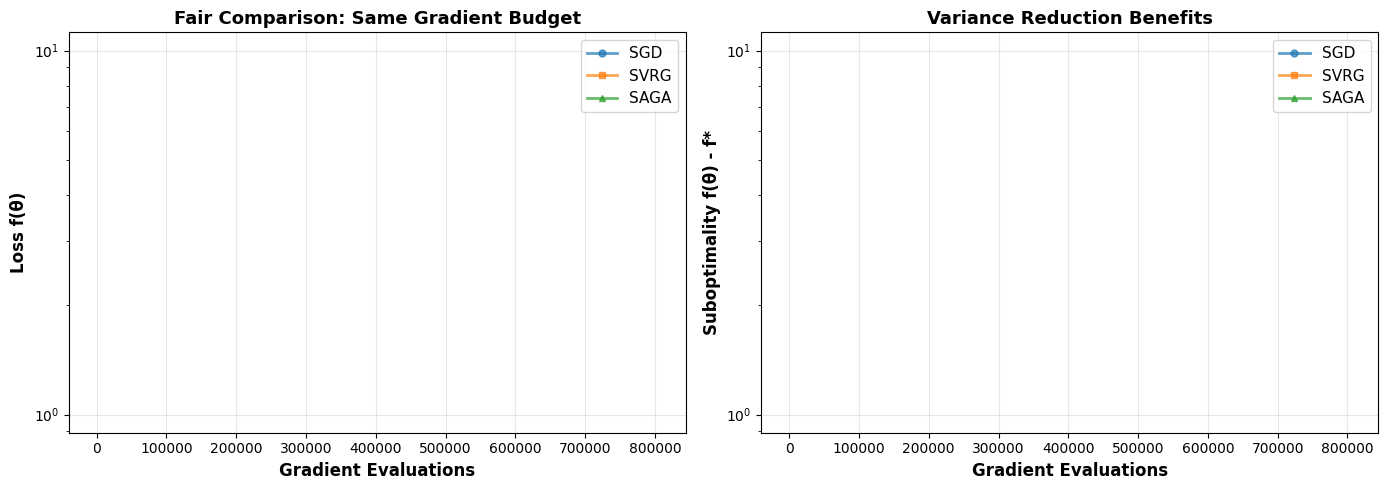

In [ ]:
# Visualization: Fair comparison with gradient budget
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Loss vs gradient evaluations
ax = axes[0]
ax.semilogy(result_sgd_ex3['grad_evals'], result_sgd_ex3['loss'], 'o-', 
            label='SGD', linewidth=2, markersize=5, alpha=0.7, color='#1f77b4')
ax.semilogy(result_svrg_ex3['grad_evals'], result_svrg_ex3['loss'], 's-', 
            label='SVRG', linewidth=2, markersize=5, alpha=0.7, color='#ff7f0e')
ax.semilogy(result_saga_ex3['grad_evals'], result_saga_ex3['loss'], '^-', 
            label='SAGA', linewidth=2, markersize=5, alpha=0.7, color='#2ca02c')
ax.set_xlabel('Gradient Evaluations', fontsize=12, fontweight='bold')
ax.set_ylabel('Loss f(θ)', fontsize=12, fontweight='bold')
ax.set_title('Fair Comparison: Same Gradient Budget', fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, alpha=0.3)

# Plot 2: Suboptimality vs gradient evaluations
ax = axes[1]
ax.semilogy(result_sgd_ex3['grad_evals'], result_sgd_ex3['subopt'], 'o-', 
            label='SGD', linewidth=2, markersize=5, alpha=0.7, color='#1f77b4')
ax.semilogy(result_svrg_ex3['grad_evals'], result_svrg_ex3['subopt'], 's-', 
            label='SVRG', linewidth=2, markersize=5, alpha=0.7, color='#ff7f0e')
ax.semilogy(result_saga_ex3['grad_evals'], result_saga_ex3['subopt'], '^-', 
            label='SAGA', linewidth=2, markersize=5, alpha=0.7, color='#2ca02c')
ax.set_xlabel('Gradient Evaluations', fontsize=12, fontweight='bold')
ax.set_ylabel('Suboptimality f(θ) - f*', fontsize=12, fontweight='bold')
ax.set_title('Variance Reduction Benefits', fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Questions 2.2:

1. Compare the three methods (SGD, SVRG, SAGA). Which method achieves the lowest loss per gradient evaluation and why? Discuss the roles of variance reduction, snapshot/table overhead, and batch size in explaining their relative performance.

2. Explain the extra computational costs behind SVRG and SAGA (full-gradient snapshot in SVRG, gradient-table maintenance in SAGA). How do these overheads trade off against variance reduction when the batch size or dataset size changes?

3. Discuss learning-rate sensitivity for each method. Which method(s) need more careful tuning and why? 

4. For which problem regimes (e.g., very high gradient variance, very large n, limited memory) would you recommend using SVRG or SAGA instead of plain SGD? Give concrete trade-offs and limitations for each recommendation.
